In [19]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import GPy
from datetime import datetime
str(datetime.now())

'2024-07-27 13:07:56.573361'

In [20]:
# Load the H5AD file
adata_original = sc.read_h5ad('ovary_Puck_230517_39.h5ad')

adata = adata_original.copy()

# Isolate the spatial coordinates
coordinates = pd.DataFrame(adata.obsm["spatial"], columns = ['x','y'], index = adata.obs_names)

# Isolate the most explainatory genes
def isolate_gene_values (gene_name):
    gene_values = pd.DataFrame(adata[:, gene_name].X.toarray(), columns = [gene_name], index = adata.obs_names)
    return gene_values
var1_name = "Serpine2"
var2_name = "Tagln"

# Create the df with coordinates and biomarkers of interest
df = pd.concat([coordinates, isolate_gene_values(var1_name),isolate_gene_values(var2_name)], axis =1)


# df.replace(0, pd.NA, inplace=True)
df = df.dropna()
df = df.sample(frac=1)

df = df.head(6000)

df['x'] = df['x']/df['x'].median()
df['y'] = df['y']/df['y'].median()
# df[var1_name] = df[var1_name]/df[var1_name].median()
# df[var2_name] = df[var2_name]/df[var2_name].median()

In [21]:
df

,x,y,Serpine2,Tagln
TGTGGCGCAGGCGG-1-2,1.343268,1.111091,137.174225,0.000000
GGTAGATTGGGTAC-1-2,0.924119,0.869581,0.000000,0.000000
CTGCTGGAGACAAC-1-2,0.689867,0.943309,0.000000,0.000000
TTGACGGACCTCAG-1-2,1.305188,1.120514,112.485939,0.000000
GANTGAATTTTTAA-1-2,0.985971,1.206660,401.606476,0.000000
...,...,...,...,...
TCGATCTACAGGAA-1-2,0.770017,0.792084,0.000000,0.000000
CCATGTCTAGGGCC-1-2,1.073309,1.543036,0.000000,1923.076660
TTTTGAGGATTTCA-1-2,1.161174,1.058317,0.000000,0.000000
GTTAGTTATATGAA-1-2,0.791250,1.264348,0.000000,0.000000


As of Mon 12th of Oct running on devel branch of GPy 0.8.8

In [22]:
# plotting instructions: it is better to not use the following line
# GPy.plotting.change_plotting_library('plotly')

# only write m.plot() for plots.  That is enough.

# Gaussian process regression tutorial

### Nicolas Durrande 2013
#### with edits by James Hensman and Neil D. Lawrence

We will see in this tutorial the basics for building a 1 dimensional and a 2 dimensional Gaussian process regression model, also known as a kriging model.

We first import the libraries we will need:

## 2-dimensional example

Here is a 2 dimensional example:

In [23]:
%%time 
# Extract coordinates and variables
X = df[['x', 'y']].values
Y = df[[var1_name, var2_name]].values

# define kernel
ker = GPy.kern.Matern52(input_dim=2,ARD=True) + GPy.kern.White(2)

# create simple GP model
m = GPy.models.GPRegression(X,Y,ker)

# optimize and plot
m.optimize(messages=True)

CPU times: user 10min 2s, sys: 3min 34s, total: 13min 36s
Wall time: 9min 30s


In [24]:
m.param_array

array([3.47089575e+04, 5.12663466e-02, 7.32825066e-02, 1.54962287e+04,
       1.54962287e+04])

In [25]:
# fig = m.plot()
# m.plot()
m.optimize_restarts(num_restarts = 10)

 /home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/paramz/transformations.py:111: RuntimeWarning:overflow encountered in expm1


Optimization restart 1/10, f = 79843.84115331467
Optimization restart 2/10, f = 84373.30001006252
Optimization restart 3/10, f = 79891.32686407733
Optimization restart 4/10, f = 79843.8411535568
Optimization restart 5/10, f = 79908.90936482191
Optimization restart 6/10, f = 79940.81132515073


 /home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/GPy/kern/src/stationary.py:166: RuntimeWarning:overflow encountered in divide
 /home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/GPy/kern/src/stationary.py:137: RuntimeWarning:overflow encountered in square
 /home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/GPy/kern/src/stationary.py:138: RuntimeWarning:invalid value encountered in add


Optimization restart 7/10, f = 80059.75600745883
Optimization restart 8/10, f = 81415.78071818808
Optimization restart 9/10, f = 80008.51008881164
Optimization restart 10/10, f = 80122.26640721092


In [26]:
# # 1: Saving a model:
# np.save('model_save.npy', m.param_array)

# # 2: loading a model
# np.load('model_save.npy')
m.param_array

array([3.47089575e+04, 5.12696581e-02, 7.32476788e-02, 1.54962287e+04,
       1.54962287e+04])

The flag `ARD=True` in the definition of the `Matern` kernel specifies that we want one lengthscale parameter per dimension (ie the GP is not isotropic). Note that for 2-d plotting, only the mean is shown. 

In [27]:
X_new = np.random.uniform(-2., 2., (500, 2))
Y_pred, Y_var = m.predict(X_new)

In [28]:
Y_pred[:,1]

array([-4.08105220e-04, -8.44757062e-38, -5.34645151e-26, -7.73195491e-17,
       -1.69222519e-31,  7.39195036e-29, -1.08425384e-24, -2.45502545e-05,
        9.81004386e-21,  4.68358435e-03, -3.49170554e-01,  2.33851743e-04,
       -2.47338975e-49,  1.47023051e-10, -8.13397667e-33, -6.91203996e-28,
        2.27653147e-18, -4.80184933e-30, -2.26178153e-40, -9.35699144e-27,
        2.76736641e-03, -9.26029129e-09,  1.38691748e-01, -1.94895013e-06,
        3.77493395e-28, -3.51638299e-09,  4.78845349e-24, -1.14854769e-15,
       -5.44771304e-04, -6.29941386e-25, -6.08970881e-07, -1.12606501e-33,
        1.06627008e+00, -3.28463791e-09, -8.97236347e-39, -2.87859454e-35,
       -3.39495647e-22,  1.52074717e-15,  7.42602594e-10, -1.19139215e-29,
        6.68092642e-23,  9.84210527e-15,  2.69316785e-03, -4.21209166e-08,
        1.13976996e-01, -3.29283936e-41, -3.04389745e-31,  2.28410646e-20,
       -8.57493536e-53, -1.25633957e-08,  7.08210058e-29,  3.23529425e-27,
       -1.67408831e-35,  

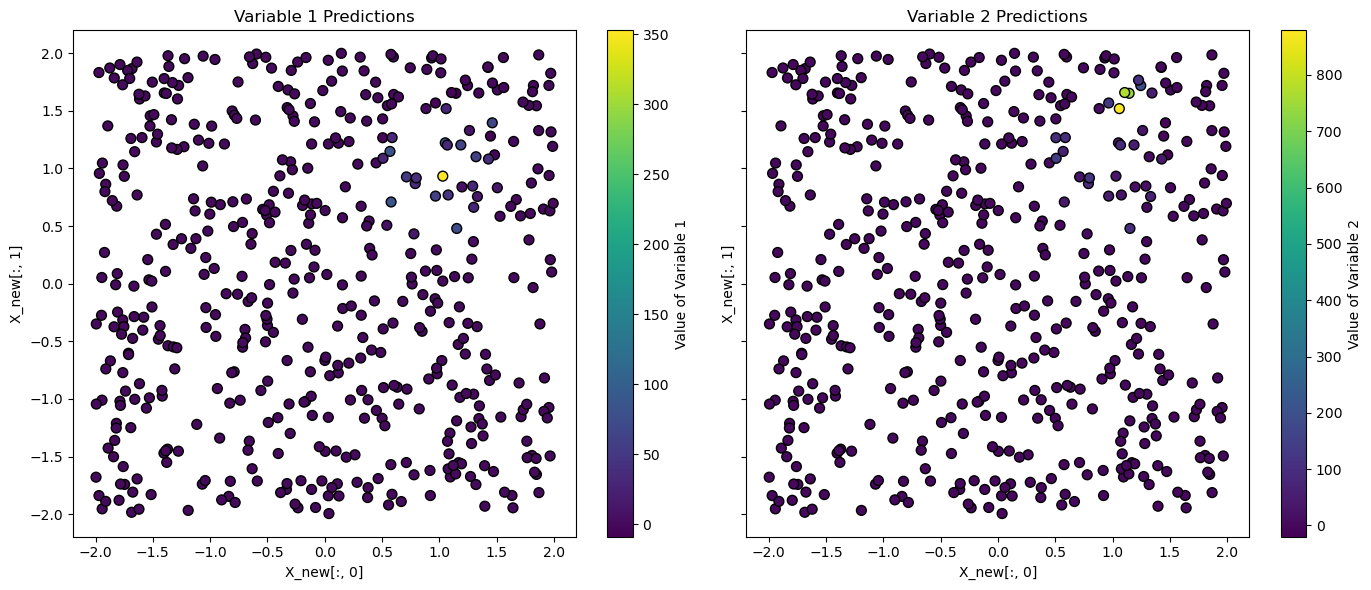

In [29]:
# Setup plot
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot for the first variable
sc1 = axs[0].scatter(X_new[:, 0], X_new[:, 1], c=Y_pred[:, 0], cmap='viridis', edgecolor='k', s=50)
fig.colorbar(sc1, ax=axs[0], label='Value of Variable 1')
axs[0].set_title('Variable 1 Predictions')
axs[0].set_xlabel('X_new[:, 0]')
axs[0].set_ylabel('X_new[:, 1]')

# Plot for the second variable
sc2 = axs[1].scatter(X_new[:, 0], X_new[:, 1], c=Y_pred[:, 1], cmap='viridis', edgecolor='k', s=50)
fig.colorbar(sc2, ax=axs[1], label='Value of Variable 2')
axs[1].set_title('Variable 2 Predictions')
axs[1].set_xlabel('X_new[:, 0]')
axs[1].set_ylabel('X_new[:, 1]')

# Show plot
plt.tight_layout()
plt.show()

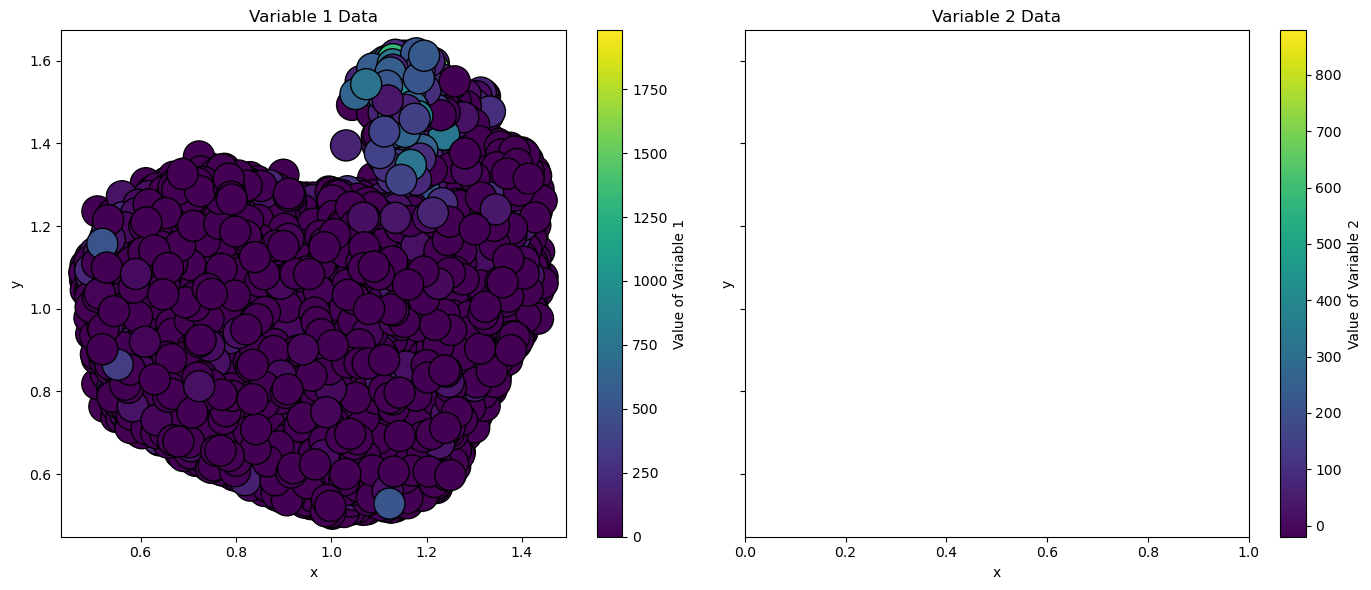

In [30]:
# Setup plot
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot for the first variable
sc1 = axs[0].scatter(df['x'], df['y'], c=df[var1_name], cmap='viridis', edgecolor='k', s=5)
fig.colorbar(sc1, ax=axs[0], label='Value of Variable 1')
axs[0].set_title('Variable 1 Data')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

# Plot for the second variable
sc1 = axs[0].scatter(df['x'], df['y'], c=df[var2_name], cmap='viridis', edgecolor='k', s=500)
fig.colorbar(sc2, ax=axs[1], label='Value of Variable 2')
axs[1].set_title('Variable 2 Data')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')

# Show plot
plt.tight_layout()
plt.show()

<Axes: >

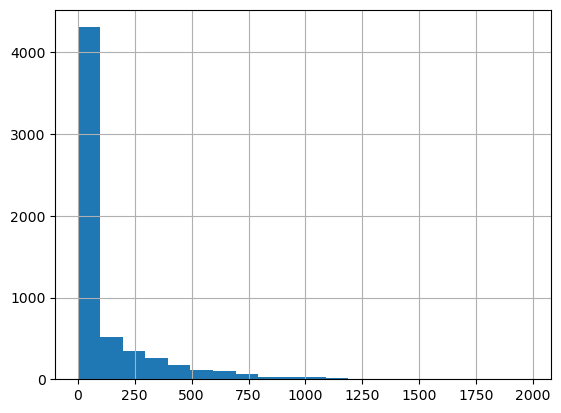

In [31]:
df[var1_name].hist(bins=20)

<Axes: >

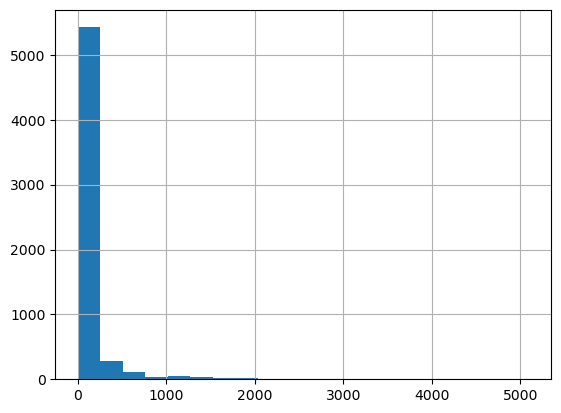

In [32]:
df[var2_name].hist(bins=20)

In [33]:
str(datetime.now())

'2024-07-27 14:43:39.357013'